# Step 0: Load the datasets and import libs

In [38]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv(r"data/Reviews.csv",index_col="Id")

df.shape

(568454, 9)

# Step 1: EDA ⛏️

In [39]:
df.head()

,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
Id,,,,,,,,,
1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


Note:

- HelpfulnessNumerator: The subset of voters who marked the review as "helpful".
- HelpfulnessDenominator: The total set of voters who indicated whether they found the review helpful or not (including positive and negative votes).

In [40]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 568454 entries, 1 to 568454
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   ProductId               568454 non-null  object
 1   UserId                  568454 non-null  object
 2   ProfileName             568428 non-null  object
 3   HelpfulnessNumerator    568454 non-null  int64 
 4   HelpfulnessDenominator  568454 non-null  int64 
 5   Score                   568454 non-null  int64 
 6   Time                    568454 non-null  int64 
 7   Summary                 568427 non-null  object
 8   Text                    568454 non-null  object
dtypes: int64(4), object(5)
memory usage: 43.4+ MB


,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,1.743817,2.22881,4.183199,1.296257e+09
std,7.636513,8.28974,1.310436,4.804331e+07
min,0.000000,0.00000,1.000000,9.393408e+08
25%,0.000000,0.00000,4.000000,1.271290e+09
50%,0.000000,1.00000,5.000000,1.311120e+09
75%,2.000000,2.00000,5.000000,1.332720e+09
max,866.000000,923.00000,5.000000,1.351210e+09


- we can notice that there are some missing values in the "ProfileName" and "Summary" columns, we will drop those rows out

In [41]:
df.dropna(subset=["ProfileName","Summary"], inplace=True)

In [42]:
df.isnull().sum()

ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

<Axes: title={'center': 'Distribution of review scores'}, xlabel='Score'>

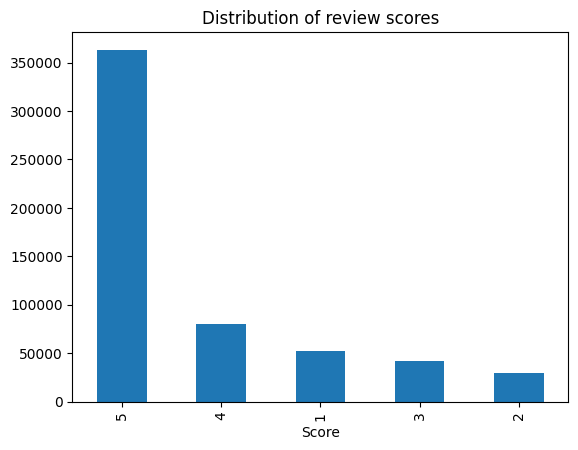

In [43]:
# plot kinds: ('line', 'bar', 'barh', 'kde', 'density', 'area', 'hist', 'box', 'pie', 'scatter', 'hexbin')
df["Score"].value_counts().plot(kind="bar",title="Distribution of review scores")

In [44]:
df["text_length"] = df["Text"].apply(len)
df["word_count"] = df["Text"].apply(lambda x: len(x.split()))

In [45]:
df.head()

,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,text_length,word_count
Id,,,,,,,,,,,
1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,263,48
2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,190,31
3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,509,94
4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,219,41
5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,140,27


# NLTK ✍️ (Simple Example)

In [46]:
import nltk

# nltk.download()

In [47]:
sample_text = df["Text"][382]
sample_text

'These condiments are overpriced and terrible. The classic is disgustingly sweet. The spiced tastes like a bad spicy marinara sauce from a chain restaurant.'

In [48]:
tokens = nltk.word_tokenize(sample_text)
print(tokens)

['These', 'condiments', 'are', 'overpriced', 'and', 'terrible', '.', 'The', 'classic', 'is', 'disgustingly', 'sweet', '.', 'The', 'spiced', 'tastes', 'like', 'a', 'bad', 'spicy', 'marinara', 'sauce', 'from', 'a', 'chain', 'restaurant', '.']


In [49]:
tags=nltk.pos_tag(tokens)
print(tags)
# u can see the abrreviations of the tags here: https://www.ling.upenn.edu/courses/Fall_2003/ling001/penn_treebank_pos.html

[('These', 'DT'), ('condiments', 'NNS'), ('are', 'VBP'), ('overpriced', 'VBN'), ('and', 'CC'), ('terrible', 'JJ'), ('.', '.'), ('The', 'DT'), ('classic', 'JJ'), ('is', 'VBZ'), ('disgustingly', 'RB'), ('sweet', 'JJ'), ('.', '.'), ('The', 'DT'), ('spiced', 'JJ'), ('tastes', 'NNS'), ('like', 'IN'), ('a', 'DT'), ('bad', 'JJ'), ('spicy', 'NN'), ('marinara', 'NN'), ('sauce', 'NN'), ('from', 'IN'), ('a', 'DT'), ('chain', 'NN'), ('restaurant', 'NN'), ('.', '.')]


In [50]:
chunks=nltk.chunk.ne_chunk(tags)
# print(chunks) # this normal print will give you an error because of the tree structure of the chunks. To visualize it, we can use the following code: 
chunks.draw()
# or we can use pprint (pretty print) to print the chunks in a more readable format:
from pprint import pprint
pprint(chunks)

Tree('S', [('These', 'DT'), ('condiments', 'NNS'), ('are', 'VBP'), ('overpriced', 'VBN'), ('and', 'CC'), ('terrible', 'JJ'), ('.', '.'), ('The', 'DT'), ('classic', 'JJ'), ('is', 'VBZ'), ('disgustingly', 'RB'), ('sweet', 'JJ'), ('.', '.'), ('The', 'DT'), ('spiced', 'JJ'), ('tastes', 'NNS'), ('like', 'IN'), ('a', 'DT'), ('bad', 'JJ'), ('spicy', 'NN'), ('marinara', 'NN'), ('sauce', 'NN'), ('from', 'IN'), ('a', 'DT'), ('chain', 'NN'), ('restaurant', 'NN'), ('.', '.')])


***

# STEP 2: VADER

## 📖 Definition 

- VADER stands for Valence Aware Dictionary and sEntiment Reasoner. It is a lexicon-based sentiment analysis tool mainly designed for analyzing sentiment in social media text but it also works well for reviews, comments, short messages, and informal text.

- It determines whether a piece of text is:

    - Positive
    - Negative
    - Neutral

It also gives a `compound score`, which is an overall sentiment score between:

<span style="font-size:40px"> -1 to 1</span>

Where:

- close to +1 → very positive
- close to -1 → very negative
- close to 0 → neutral

---

## 💪 Why VADER is Special

Unlike simple word counting, VADER understands things like:

1. Capital Letters

- Example:

    - "This is good" → positive
    - "This is GOOD" → more positive

because capitalization adds intensity.

<p style="text-align:center;">────────────</p>

2. Punctuation

- Example:

    - "Amazing"
    - "Amazing!!!"

More exclamation marks = stronger sentiment.

<p style="text-align:center;">────────────</p>

3. Degree Modifiers

- Example:

    - "good"
    - "very good"
    - "extremely good"

Words like very, extremely, slightly affect intensity.

4. Negation Handling

<p style="text-align:center;">────────────</p>

Example:

- "good" → positive
- "not good" → negative

VADER handles negation well

5. Emojis and Slang

<p style="text-align:center;">────────────</p>

- Example:

    - ":)"
    - "LOL"
    - "meh"

This is why it works especially well for social media.

---

## 💚 Advantages
- Very fast
- No training data needed
- Great for short text
- Handles informal language well
- Easy to use

<p style="text-align:center;">────────────</p>

## 💔 Limitations
- Not great for very domain-specific text
- (like medical/legal text)
- May struggle with deep sarcasm

---

## Code

We will use NLTK's `SentimentIntensityAnalyzer` to get the score of a text
- This uses a "Bag of Words" approach
    1. Remove stop words
    2. Each word is scored and combined to a total score

In [51]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

In [52]:
sia.polarity_scores("I'm so happy today!")

{'neg': 0.0, 'neu': 0.412, 'pos': 0.588, 'compound': 0.6468}

In [53]:
sia.polarity_scores("I'm so HAPPY today!")

{'neg': 0.0, 'neu': 0.374, 'pos': 0.626, 'compound': 0.72}

In [54]:
sia.polarity_scores("I'm so sad today!")

{'neg': 0.551, 'neu': 0.449, 'pos': 0.0, 'compound': -0.5697}

In [55]:
print(sample_text)
sia.polarity_scores(sample_text)

These condiments are overpriced and terrible. The classic is disgustingly sweet. The spiced tastes like a bad spicy marinara sauce from a chain restaurant.


{'neg': 0.318, 'neu': 0.515, 'pos': 0.167, 'compound': -0.7184}

In [56]:
# import tqdm for progress bar
from tqdm.notebook import tqdm

res={}

for i, row in tqdm(df.head(1000).iterrows(), total=1000):
    text=row["Text"]
    my_id=row.name
    res[my_id]=sia.polarity_scores(text)

res_df=pd.DataFrame(res)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [57]:
res_df

,1,2,3,4,5,6,7,8,9,10,...,991,992,993,994,995,996,997,998,999,1000
neg,0.0000,0.1380,0.0910,0.0,0.0000,0.029,0.0340,0.0000,0.0000,0.0000,...,0.032,0.0000,0.0000,0.0000,0.0000,0.0260,0.0000,0.0000,0.0630,0.0270
neu,0.6950,0.8620,0.7540,1.0,0.5520,0.809,0.6930,0.5200,0.8510,0.7050,...,0.667,0.6330,0.6620,0.8860,0.8280,0.7210,0.7860,0.6730,0.8740,0.9390
pos,0.3050,0.0000,0.1550,0.0,0.4480,0.163,0.2730,0.4800,0.1490,0.2950,...,0.301,0.3670,0.3380,0.1140,0.1720,0.2530,0.2140,0.3270,0.0620,0.0340
compound,0.9441,-0.5664,0.8265,0.0,0.9468,0.883,0.9346,0.9487,0.6369,0.8313,...,0.973,0.9749,0.9636,0.8858,0.7552,0.9788,0.9309,0.9634,-0.0129,-0.1027


In [58]:
res_df=res_df.T
res_df

,neg,neu,pos,compound
1,0.000,0.695,0.305,0.9441
2,0.138,0.862,0.000,-0.5664
3,0.091,0.754,0.155,0.8265
4,0.000,1.000,0.000,0.0000
5,0.000,0.552,0.448,0.9468
...,...,...,...,...
996,0.026,0.721,0.253,0.9788
997,0.000,0.786,0.214,0.9309
998,0.000,0.673,0.327,0.9634
999,0.063,0.874,0.062,-0.0129


merging and Resizing the dataset just for simplicity

In [59]:
df=df.head(1000).merge(res_df, left_index=True, right_index=True)

df.head()

,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,text_length,word_count,neg,neu,pos,compound
Id,,,,,,,,,,,,,,,
1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,263,48,0.000,0.695,0.305,0.9441
2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,190,31,0.138,0.862,0.000,-0.5664
3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,509,94,0.091,0.754,0.155,0.8265
4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,219,41,0.000,1.000,0.000,0.0000
5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,140,27,0.000,0.552,0.448,0.9468


In [60]:
df.shape

(1000, 15)

## Plot

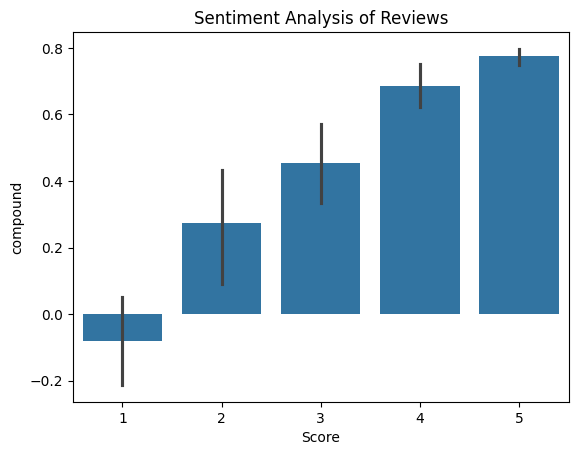

In [68]:
import seaborn as sns
ax=sns.barplot(data=df, x="Score", y="compound")
ax.set_title("Sentiment Analysis of Reviews")
plt.show()
